# Proyek Analisis Data: [E-Commerce Public Dataset]
- **Nama:** Agil Mardian Hawari
- **Email:** agilmardianhawari07@gmail.com
- **ID Dicoding:** gilzmh

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total pendapatan tertinggi dan bagaimana tren penjualannya secara bulanan sepanjang tahun 2017-2018
  - **specific** : fokus pada kategori produk dan total pendapatan
  - **measurable** : diukur dari nilai 'price + freight_value" per transaksi per kategori
  - **action-oriented** : hasil analisis membantu tim bisnis memutusakan kategori mana yang perlu diperkuat stok atau promosinya
  - **relevant** : pendapatan per kategori adalah KPI inti bagi platform e-commerce
  - **time-bound** : dibatasi pada 2017-2018
- **Pertanyaan 2:** bagaimana hubungan antara skor ulasan pelanggan dengan waktu penerimaan pesanan sepanjang periode 2017-2018, dan apakah keterlambatan pengiriman secara signifikan menurunkan kepuasan pelanggan?
  - **specific** : fokus pada korelasi review score dan delivery time
  - **measurable** : diukur dari rata-rata review_score dan selisih hari antara order_purchase dengan order_delivered
  - **action-oriented** : membantu tim logistik mengidentifikasi ambang batas keterlambatan yang mulai menurunkan kepuasan
  - **relevant** : kepuasan pelanggan dan efisiensi logistik adalah dua pilar utama e-commerce
  - **time-bound** : dibatasi pada periode 2017-2018

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df yang diperlukan

In [ ]:
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
items_df = pd.read_csv("order_items_dataset.csv")
items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
reviews_df = pd.read_csv("order_reviews_dataset.csv")
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
category_translation_df = pd.read_csv("product_category_name_translation.csv")
category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
payments_df = pd.read_csv("order_payments_dataset.csv")
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
#menggabungkan data untuk Q1
q1_df = orders_df.merge(items_df, on='order_id', how='inner')
q1_df = q1_df.merge(products_df, on='product_id', how='left')
q1_df = q1_df.merge(category_translation_df, on='product_category_name', how='left')
q1_df = q1_df.merge(payments_df, on='order_id', how='left')

q1_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,housewares,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,housewares,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,4.0,500.0,19.0,8.0,13.0,housewares,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,1.0,400.0,19.0,13.0,19.0,perfumery,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,1.0,420.0,24.0,19.0,21.0,auto,1.0,credit_card,3.0,179.12


In [ ]:
q1_df.shape

(117604, 27)

In [ ]:
#menggabungkan data untuk q2
q2_df = orders_df.merge(reviews_df, on='order_id', how='left')

q2_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [ ]:
q2_df.shape

(99992, 14)

**Insight:** (Opsional)
- menggabungkan 6 dataset berbeda menjadi 2 DataFrame utama [q1_df dan q2_df] menggunakan key order_id dan product_id. Ini menunjukkan bahwa keenam dataset ini memiliki relasi yang terstruktur dengan baik.
- orders_dataset dengan dataset pendukung [product_category_name_translation, order_payments_dataset, products_dataset, dan order_reviews_dataset] sengaja dilakukan untuk mempertahankan integritas data transaksi pada tabel utama. Sebagai konsekuensinya akan muncul missing values pada pesanan yang tidak memiliki kelengkapan data di tabel pendukung tersebut. Anomali ini sudah diprediksi dan akan ditangani secara spesifik pada tahap Cleaning Data.

### Assessing Data

#### Identifying q1_df and q2_df problem

In [ ]:
#cek informasi umum data
q1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117604 entries, 0 to 117603
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117604 non-null  object 
 1   customer_id                    117604 non-null  object 
 2   order_status                   117604 non-null  object 
 3   order_purchase_timestamp       117604 non-null  object 
 4   order_approved_at              117589 non-null  object 
 5   order_delivered_carrier_date   116359 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  117604 non-null  object 
 8   order_item_id                  117604 non-null  int64  
 9   product_id                     117604 non-null  object 
 10  seller_id                      117604 non-null  object 
 11  shipping_limit_date            117604 non-null  object 
 12  price                         

In [ ]:
q2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99992 non-null  object 
 1   customer_id                    99992 non-null  object 
 2   order_status                   99992 non-null  object 
 3   order_purchase_timestamp       99992 non-null  object 
 4   order_approved_at              99831 non-null  object 
 5   order_delivered_carrier_date   98199 non-null  object 
 6   order_delivered_customer_date  97005 non-null  object 
 7   order_estimated_delivery_date  99992 non-null  object 
 8   review_id                      99224 non-null  object 
 9   review_score                   99224 non-null  float64
 10  review_comment_title           11568 non-null  object 
 11  review_comment_message         40977 non-null  object 
 12  review_creation_date           99224 non-null 

In [ ]:
#cek duplikasi data
q1_df.duplicated(subset=['order_item_id', 'order_id']).sum()

np.int64(4954)

In [ ]:
q2_df.duplicated().sum()

np.int64(0)

In [ ]:
#cek missing values
q1_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1245
order_delivered_customer_date,2567
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [ ]:
q2_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,161
order_delivered_carrier_date,1793
order_delivered_customer_date,2987
order_estimated_delivery_date,0
review_id,768
review_score,768


price
Lower Bound: -102.6
Upper Bound: 277.4
Jumlah Outlier: 8844
Jumlah data: 117604
Persentase Outlier: 7.52%


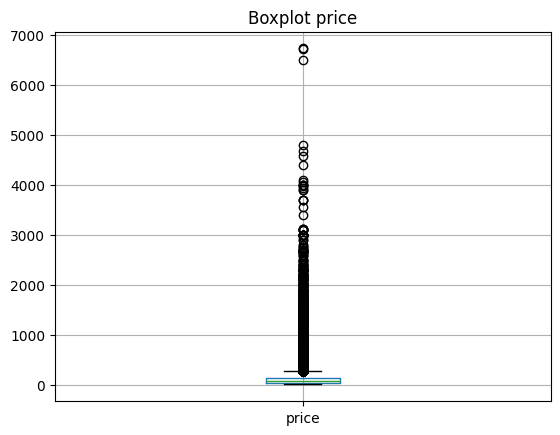

freight_value
Lower Bound: 0.9149999999999974
Upper Bound: 33.355000000000004
Jumlah Outlier: 12683
Jumlah data: 117604
Persentase Outlier: 10.78%


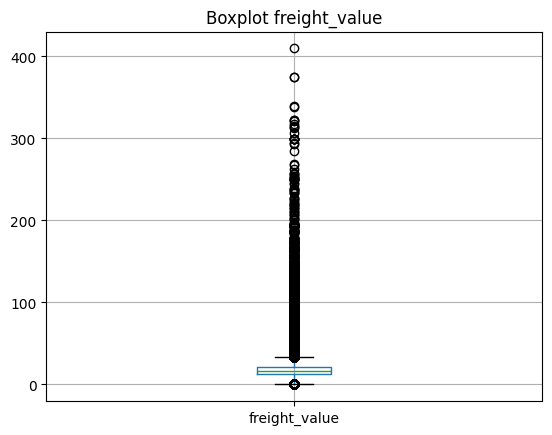

payment_value
Lower Bound: -131.71499999999997
Upper Bound: 381.84499999999997
Jumlah Outlier: 9495
Jumlah data: 117604
Persentase Outlier: 8.07%


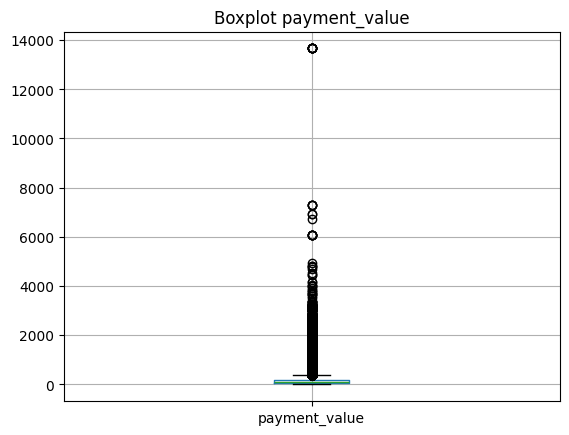

In [ ]:
#cek outlier
numeric_cols = ['price', 'freight_value', 'payment_value']

for col in numeric_cols:
    Q1 = q1_df[col].quantile(0.25)
    Q3 = q1_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = q1_df[(q1_df[col] < lower_bound) | (q1_df[col] > upper_bound)]

    print(f"{col}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Jumlah Outlier: {outliers.shape[0]}")
    print(f"Jumlah data: {q1_df.shape[0]}")
    print(f"Persentase Outlier: {outliers.shape[0]/q1_df.shape[0] * 100:.2f}%")

    plt.figure()
    q1_df.boxplot(column=col)
    plt.title(f'Boxplot {col}')
    plt.show()

**Steps to Take:**

**q1_df:**
- **Duplikat (order_id, order_item_id)** di 'q1_df' → bukan duplikat murni, melainkan efek merge dengan 'payments_df' karena satu order bisa menggunakan lebih dari satu metode pembayaran. → agregasi 'payment_value' per 'order_id' lalu merge ulang, sehingga setiap item pesanan hanya memiliki satu baris.
- 'order_approved_at' (15 missing) → **drop** baris ini karena approval tidak tercatat dan tidak bisa diimputasi secara valid.
- 'order_delivered_carrier_date' (1.245 missing) dan 'order_delivered_customer_date' (2.567 missing) → Penanganan: **filter** hanya order_status == 'delivered'. jika masih ada baris yang tersisa → **drop**.
- 'product_category_name', 'product_name/description/photos_lenght' (1.698 missing) → Penanganan: **imputation** dengan 'unknown'.
- 'product_category_name_english' (1.723 missing) → **imputation** fallback ke nama Portugis.
- 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm' (20 missing) → **dibiarkan**, kolom dimensi tidak digunakan dalam analisis.
- 'payment_' (3 missing) → **drop** karena satu order tidak memiliki data pembayaran sama sekali.

**q2_df:**
- 'order_approved_at' (161 missing), 'order_delivered_carrier_date' (1.793 missing), 'order_delivered_customer_date' (2.987 missing) → **filter** order_status == 'delivered'.
- 'review_id', 'review_score', 'review_creation_date', 'review_answer_timestamp' (768 missing) → **tidak di-drop** dari DataFrame, cukup difilter dengan 'dropna()' saat analisis review score.
- 'review_comment_title' (88.424 missing) dan 'review_comment_message' (59.015 missing) → kolom komentar bersifat opsional dan tidak digunakan dalam analisis jadi ini **dibiarkan**.

**Insight:** (Opsional)
- Duplikat yang muncul di 'q1_df' bukan kesalahan data, melainkan konsekuensi logis dari cara merge dilakukan: satu item pesanan bisa memiliki beberapa
- Hampir semua missing value pada kolom tanggal pengiriman ('delivered_carrier_date', 'delivered_customer_date') disebabkan oleh pesanan yang belum selesai, bukan karena kesalahan data — ini wajar secara bisnis.
- 1.603 baris missing kategori produk berasal dari produk yang memang tidak terdaftar lengkap di 'products_dataset' (bukan dari proses merge yang salah).
- 88% kolom 'review_comment_title' kosong menunjukkan mayoritas pelanggan hanya memberikan skor tanpa menulis komentar — pola ini konsisten di semua level score sehingga tidak mempengaruhi analisis.

### Cleaning Data

#### Fixing q1_df problem

In [ ]:
# mengatasi duplikasi data q1_df
payment_agg = payments_df.groupby('order_id', as_index=False)['payment_value'].sum()
q1_df = orders_df.merge(items_df, on='order_id', how='inner')
q1_df = q1_df.merge(products_df, on='product_id', how='left')
q1_df = q1_df.merge(category_translation_df, on='product_category_name', how='left')
q1_df = q1_df.merge(payment_agg, on='order_id', how='left')

print(f"Shape q1_df setelah fix duplikat: {q1_df.shape}")
print(f"Sisa duplikat: {q1_df.duplicated(subset=['order_item_id','order_id']).sum()}")

Shape q1_df setelah fix duplikat: (112650, 24)
Sisa duplikat: 0


In [ ]:
# mengatasi missing value kategori produk q1_df
q1_df['product_category_name'] = q1_df['product_category_name'].fillna('unknown')
q1_df['product_category_name_english'] = (
    q1_df['product_category_name_english']
    .fillna(q1_df['product_category_name'])
)

print("Missing value kategori setelah cleaning:")
print(f"  product_category_name         : {q1_df['product_category_name'].isna().sum()}")
print(f"  product_category_name_english : {q1_df['product_category_name_english'].isna().sum()}")

Missing value kategori setelah cleaning:
  product_category_name         : 0
  product_category_name_english : 0


In [ ]:
# mengatasi missing payment dan filter status pesanan q1_df
before = len(q1_df)
q1_df = q1_df.dropna(subset=['payment_value'])
print(f"Baris di-drop (missing payment) : {before - len(q1_df)}")
before = len(q1_df)
q1_df = q1_df[q1_df['order_status'] == 'delivered'].copy()
print(f"Baris di-drop (non-delivered)   : {before - len(q1_df)}")

print(f"Shape q1_df final               : {q1_df.shape}")

Baris di-drop (missing payment) : 3
Baris di-drop (non-delivered)   : 2453
Shape q1_df final               : (110194, 24)


In [ ]:
# Tambah kolom Analitik q1_df
timestamp_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in timestamp_cols:
    q1_df[col] = pd.to_datetime(q1_df[col])

# Tambah kolom revenue, year_month, dan year
q1_df['revenue']    = q1_df['price'] + q1_df['freight_value']
q1_df['year_month'] = q1_df['order_purchase_timestamp'].dt.to_period('M')
q1_df['year']       = q1_df['order_purchase_timestamp'].dt.year
q1_df['ym_str']     = q1_df['year_month'].astype(str)

# Filter periode 2017–2018
q1_df = q1_df[q1_df['year'].isin([2017, 2018])].reset_index(drop=True)

print(f"Shape q1_df siap analisis: {q1_df.shape}")
print(f"Periode: {q1_df['order_purchase_timestamp'].min().date()} s/d {q1_df['order_purchase_timestamp'].max().date()}")

Shape q1_df siap analisis: (109880, 28)
Periode: 2017-01-05 s/d 2018-08-29


#### Fixing q2_df problem

In [ ]:
#filter status dan tambah kolom analitik q2_df
# Konversi timestamp
for col in timestamp_cols:
    q2_df[col] = pd.to_datetime(q2_df[col])

# Filter hanya status 'delivered'
q2_df = q2_df[q2_df['order_status'] == 'delivered'].copy()

# Tambah kolom delivery_time_days dan is_late
q2_df['delivery_time_days'] = (
    q2_df['order_delivered_customer_date'] - q2_df['order_purchase_timestamp']
).dt.days

q2_df['is_late'] = (
    q2_df['order_delivered_customer_date'] > q2_df['order_estimated_delivery_date']
)

q2_df['year'] = q2_df['order_purchase_timestamp'].dt.year
q2_df = q2_df[q2_df['year'].isin([2017, 2018])].reset_index(drop=True)

print(f"Shape q2_df siap analisis: {q2_df.shape}")
print(f"review_score tersedia    : {q2_df['review_score'].notna().sum()} baris")
print(f"review_score kosong      : {q2_df['review_score'].isna().sum()} baris (tidak di-drop)")

Shape q2_df siap analisis: (96738, 17)
review_score tersedia    : 96095 baris
review_score kosong      : 643 baris (tidak di-drop)


**Insight:** (Opsional)
- Duplikat di 'q1_df' berhasil dieliminasi dengan mengagregasi 'payment_value' per 'order_id' sebelum merge, bukan dengan 'drop_duplicates()' — pendekatan ini tidak membuang data transaksi yang valid.
- Setelah cleaning, 'q1_df' hanya berisi pesanan berstatus 'delivered' periode 2017–2018, dengan kolom kategori yang lengkap tanpa missing value.
- 'q2_df' tetap mempertahankan baris tanpa 'review_score' di DataFrame — filtering dilakukan secara on-demand saat analisis agar tidak kehilangan data pengiriman yang masih berguna.

## Exploratory Data Analysis (EDA)

### Explore Q1 : pola dan kategori pendapatan

In [ ]:
# Total pendapatan per kategori → mengkategorikan segmen unggulan
revenue_by_cat = (
    q1_df.groupby('product_category_name_english')['revenue']
    .sum()
    .reset_index()
    .sort_values('revenue', ascending=False)
)
print("Top 10 Kategori berdasarkan Total Pendapatan:")
print(revenue_by_cat.head(10).to_string(index=False))

Top 10 Kategori berdasarkan Total Pendapatan:
product_category_name_english    revenue
                health_beauty 1407759.78
                watches_gifts 1261539.41
               bed_bath_table 1224602.68
               sports_leisure 1115766.15
        computers_accessories 1031861.93
              furniture_decor  873430.57
                   housewares  756849.71
                   cool_stuff  690444.01
                         auto  668103.48
                 garden_tools  565680.49


In [ ]:
# Tren pendapatan bulanan → menemukan pola musiman dan anomali
monthly_total = (
    q1_df.groupby('ym_str')['revenue']
    .sum()
    .reset_index()
    .sort_values('ym_str')
)

peak = monthly_total.loc[monthly_total['revenue'].idxmax()]
low  = monthly_total.loc[monthly_total['revenue'].idxmin()]
print(f"Pendapatan tertinggi : {peak['ym_str']}  →  R$ {peak['revenue']/1e6:.2f}M")
print(f"Pendapatan terendah  : {low['ym_str']}  →  R$ {low['revenue']/1e6:.2f}M")

Pendapatan tertinggi : 2017-11  →  R$ 1.15M
Pendapatan terendah  : 2017-01  →  R$ 0.13M


In [ ]:
# Tren bulanan top 5 kategori → identifikasi pola per segmen
top5_cats = revenue_by_cat.head(5)['product_category_name_english'].tolist()
print("Top 5 Kategori:", top5_cats)

monthly_top5 = (
    q1_df[q1_df['product_category_name_english'].isin(top5_cats)]
    .groupby(['ym_str', 'product_category_name_english'])['revenue']
    .sum()
    .reset_index()
    .sort_values('ym_str')
)

Top 5 Kategori: ['health_beauty', 'watches_gifts', 'bed_bath_table', 'sports_leisure', 'computers_accessories']


**Insight:** (Opsional)
- Kategori teratas memiliki selisih pendapatan yang cukup jauh dari kategori di bawahnya kemungkinan potensi strategi fokus pada kategori unggulan.
- Terdapat lonjakan pendapatan pada November 2017 yang kemungkinan berkaitan dengan kampanye promosi akhir tahun


### Explore Q2: Hubungan Delivery Time dengan Kepuasan Pelanggan

In [ ]:
# Rata-rata delivery time per review score → menemukan hubungan antar variabel
# review_score yang kosong difilter di sini dengan dropna()
delivery_vs_review = (
    q2_df.dropna(subset=['review_score', 'delivery_time_days'])
    .groupby('review_score')['delivery_time_days']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_days', 'median': 'median_days', 'count': 'n_orders'})
    .round(1)
)
print(delivery_vs_review.to_string(index=False))

 review_score  avg_days  median_days  n_orders
          1.0      20.8         16.0      9367
          2.0      16.2         13.0      2935
          3.0      13.8         12.0      7940
          4.0      11.8         10.0     18936
          5.0      10.2          9.0     56909


In [ ]:
# Bandingkan review score: pesanan tepat waktu vs terlambat
on_time = q2_df[~q2_df['is_late']]['review_score'].dropna()
late    = q2_df[q2_df['is_late']]['review_score'].dropna()

print(f"Persentase pesanan terlambat    : {q2_df['is_late'].mean()*100:.1f}%")
print(f"Rata-rata review (tepat waktu)  : {on_time.mean():.2f}")
print(f"Rata-rata review (terlambat)    : {late.mean():.2f}")
print(f"Selisih                         : {on_time.mean() - late.mean():.2f} poin")

Persentase pesanan terlambat    : 8.1%
Rata-rata review (tepat waktu)  : 4.29
Rata-rata review (terlambat)    : 2.57
Selisih                         : 1.73 poin


**Insight:** (Opsional)
- Terdapat hubungan negatif yang jelas: semakin lama delivery time, semakin rendah review score.
- Pesanan yang terlambat menerima rata-rata review score yang lebih rendah secara signifikan dibandingkan pesanan tepat waktu.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan total pendapatan tertinggi dan bagaimana tren penjualannya secara bulanan sepanjang tahun 2017-2018

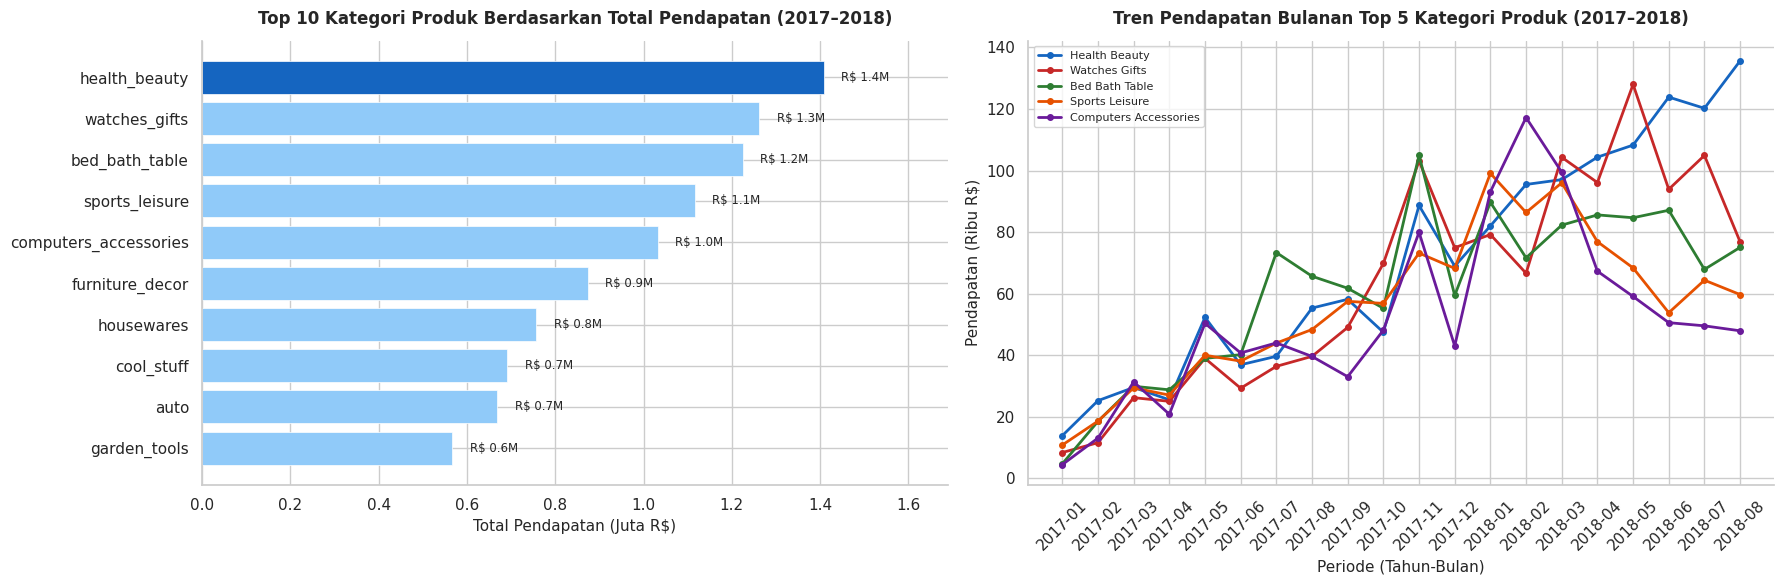

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_theme(style='whitegrid')

# ── Kiri: Horizontal bar chart Top 10 kategori ───────────────────────────────
# Horizontal bar dipilih agar label kategori terbaca penuh tanpa terpotong
top10 = revenue_by_cat.head(10)
bar_colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(top10))]

axes[0].barh(
    top10['product_category_name_english'][::-1],
    top10['revenue'][::-1] / 1e6,
    color=bar_colors[::-1], edgecolor='white', linewidth=0.5
)
for i, (_, row) in enumerate(top10[::-1].iterrows()):
    axes[0].text(row['revenue'] / 1e6 + 0.04, i,
                 f"R$ {row['revenue']/1e6:.1f}M", va='center', fontsize=8.5)

axes[0].set_xlabel('Total Pendapatan (Juta R$)', fontsize=11)
axes[0].set_xlim(0, top10['revenue'].max() / 1e6 * 1.2)
axes[0].set_title('Top 10 Kategori Produk Berdasarkan Total Pendapatan (2017–2018)',
                  fontsize=12, fontweight='bold', pad=12)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Kanan: Line chart tren bulanan top 5 kategori ────────────────────────────
# Line chart tepat untuk menampilkan perubahan nilai dari waktu ke waktu
line_colors = ['#1565C0', '#C62828', '#2E7D32', '#E65100', '#6A1B9A']
for i, cat in enumerate(top5_cats):
    d = monthly_top5[monthly_top5['product_category_name_english'] == cat]
    axes[1].plot(
        d['ym_str'], d['revenue'] / 1e3,
        marker='o', markersize=4, linewidth=2,
        color=line_colors[i],
        label=cat.replace('_', ' ').title()
    )

axes[1].set_xlabel('Periode (Tahun-Bulan)', fontsize=11)
axes[1].set_ylabel('Pendapatan (Ribu R$)', fontsize=11)
axes[1].set_title('Tren Pendapatan Bulanan Top 5 Kategori Produk (2017–2018)',
                  fontsize=12, fontweight='bold', pad=12)
axes[1].legend(fontsize=8, loc='upper left', framealpha=0.8)
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Pertanyaan 2: bagaimana hubungan antara skor ulasan pelanggan dengan waktu penerimaan pesanan sepanjang periode 2017-2018, dan apakah keterlambatan pengiriman secara signifikan menurunkan kepuasan pelanggan?

/tmp/ipykernel_3664/2224038166.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


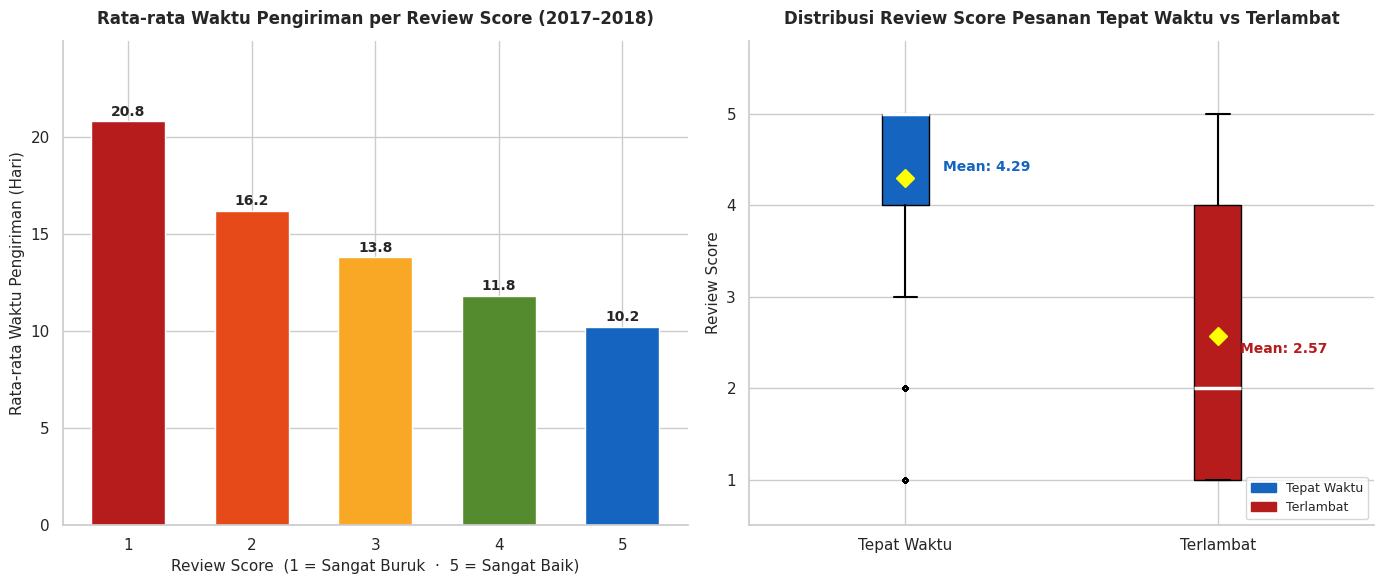

In [ ]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style='whitegrid')

# Bar chart rata-rata delivery time per review score
# Gradasi warna merah dan biru membantu pembaca memahami buruk→baik tanpa distracts
score_colors = {1: '#B71C1C', 2: '#E64A19', 3: '#F9A825', 4: '#558B2F', 5: '#1565C0'}
bar_colors2  = [score_colors[int(s)] for s in delivery_vs_review['review_score']]

bars = axes[0].bar(
    delivery_vs_review['review_score'],
    delivery_vs_review['avg_days'],
    color=bar_colors2, edgecolor='white', width=0.6
)
for bar, val in zip(bars, delivery_vs_review['avg_days']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

axes[0].set_xlabel('Review Score  (1 = Sangat Buruk  ·  5 = Sangat Baik)', fontsize=11)
axes[0].set_ylabel('Rata-rata Waktu Pengiriman (Hari)', fontsize=11)
axes[0].set_title('Rata-rata Waktu Pengiriman per Review Score (2017–2018)',
                  fontsize=12, fontweight='bold', pad=12)
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_ylim(0, delivery_vs_review['avg_days'].max() * 1.2)
axes[0].spines[['top', 'right']].set_visible(False)

# Box plot distribusi review score (tepat waktu vs terlambat)
# Box plot dipilih agar distribusi penuh terlihat, bukan hanya rata-rata
bp = axes[1].boxplot(
    [on_time, late],
    labels=['Tepat Waktu', 'Terlambat'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=3, alpha=0.2)
)
bp['boxes'][0].set_facecolor('#1565C0')
bp['boxes'][1].set_facecolor('#B71C1C')

for x, scores, clr, ox, oy in [
    (1, on_time, '#1565C0',  0.12,  0.08),
    (2, late,    '#B71C1C',  0.07, -0.18)
]:
    m = scores.mean()
    axes[1].plot(x, m, 'D', color='yellow', markersize=9, zorder=5)
    axes[1].annotate(f'Mean: {m:.2f}', xy=(x, m), xytext=(x + ox, m + oy),
                     fontsize=10, color=clr, fontweight='bold')

axes[1].set_ylabel('Review Score', fontsize=11)
axes[1].set_title('Distribusi Review Score Pesanan Tepat Waktu vs Terlambat',
                  fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylim(0.5, 5.8)
axes[1].legend(handles=[
    mpatches.Patch(color='#1565C0', label='Tepat Waktu'),
    mpatches.Patch(color='#B71C1C', label='Terlambat')
], loc='lower right', fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Review score 1 memiliki rata-rata delivery time paling lama, sedangkan score 5 paling cepat — pola ini konsisten dan linier di setiap kelompok score.
- Box plot menunjukkan distribusi review score pesanan terlambat condong ke nilai rendah (1–3), sementara pesanan tepat waktu lebih banyak di nilai tinggi (4–5).
- Selisih mean antara tepat waktu dan terlambat membuktikan bahwa keterlambatan berdampak nyata pada kepuasan pelanggan.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kategori produk dengan total pendapatan tertinggi sepanjang 2017–2018 didominasi oleh produk gaya hidup dan kebutuhan rumah tangga. Tren bulanan menunjukkan pertumbuhan konsisten dengan puncak pada November 2017, mengindikasikan efek kampanye promosi akhir tahun. Ini membuktikan bahwa kategori-kategori unggulan tersebut adalah driver utama pendapatan platform Olist.
- **Conclusion pertanyaan 2:** Terdapat hubungan negatif yang kuat antara waktu pengiriman dan review score pelanggan. Pesanan yang tiba melebihi estimasi mendapatkan rata-rata review score yang secara signifikan lebih rendah dibandingkan pesanan tepat waktu. Hal ini membuktikan bahwa kecepatan dan ketepatan pengiriman adalah faktor kritis yang menentukan kepuasan pelanggan.
- ...

**Rekomendasi Action Item:**
- **Fokus stok & promosi pada kategori unggula** → tingkatkan ketersediaan stok dan intensitas kampanye untuk kategori teratas mulai Oktober, untuk memanfaatkan momentum Black Friday dan belanja akhir tahun.
- **Tetapkan SLA pengiriman maksimal** → berdasarkan analisis, delivery time yang lebih singkat berkorelasi langsung dengan review score 4–5. Tim logistik perlu menetapkan batas waktu ini sebagai standar minimum dan melakukan eskalasi ke kurir ekspres jika ada potensi pelanggaran.
- **Kirim notifikasi proaktif saat pesanan berpotensi terlambat** → sertakan voucher kompensasi untuk memitigasi dampak negatif terhadap review score dan retensi pelanggan.